# 0. Setup

In [7]:
import re
import os, sys
import time
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path 
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely import wkb

# Add project root to Python path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
  sys.path.insert(0, str(project_root))

# Import config and setup
from config import setup_notebook, get_path
setup_notebook()

✓ Project root: /workspace/project_paaral
✓ Working directory: /workspace/project_paaral
✓ Python path updated


{'project_root': PosixPath('/workspace/project_paaral'),
 'data': PosixPath('/workspace/project_paaral/data'),
 'modules': PosixPath('/workspace/project_paaral/modules'),
 'notebooks': PosixPath('/workspace/project_paaral/notebooks'),
 'output': PosixPath('/workspace/project_paaral/output'),
 'psgc_shapefiles': PosixPath('/workspace/project_paaral/data/philippines-psgc-shapefiles/dist')}

In [3]:
!pip install -qq osmium
import osmium

# 1. Extract using PBF

## 1.1 Help functions

In [10]:
class BoundaryExtractor(osmium.SimpleHandler):
  def __init__(self, admin_level):
      super().__init__()
      self.admin_level = str(admin_level)
      self.boundaries = []
      self.wkb_factory = osmium.geom.WKBFactory()

  def area(self, a):
      if a.tags.get('boundary') == 'administrative' and \
         a.tags.get('admin_level') == self.admin_level:
          try:
              wkb_geom = self.wkb_factory.create_multipolygon(a)
              geom = wkb.loads(wkb_geom, hex=True)

              self.boundaries.append({
                  'osm_id': a.id,
                  'name': a.tags.get('name', ''),
                  'name_en': a.tags.get('name:en', ''),
                  'admin_level': a.tags.get('admin_level'),
                  'geometry': geom
              })
          except:
              pass  # Skip invalid geometries

def extract_boundaries(pbf_path, admin_level, output_path):
  """Extract administrative boundaries from PBF file"""
  handler = BoundaryExtractor(admin_level)
  handler.apply_file(str(pbf_path), locations=True)

  gdf = gpd.GeoDataFrame(handler.boundaries, crs='EPSG:4326')
  gdf.to_file(output_path)
  return gdf

## 1.2 Extract

In [ ]:
s_time = time.time()
# Usage
extract_boundaries('data/networks/philippines-251002.osm.pbf', 4, 'data/networks/ph_regions.shp')
e_time_regions = time.time() - s_time
print(f"Time elapsed: {e_time_regions} seconds.")

extract_boundaries('data/networks/philippines-251002.osm.pbf', 5, 'data/networks/ph_provinces.shp')
e_time_provs = time.time() - s_time
print(f"Time elapsed: {e_time_provs} seconds.")

extract_boundaries('data/networks/philippines-251002.osm.pbf', 6, 'data/networks/ph_cities.shp')
e_time_cms = time.time() - s_time
print(f"Time elapsed: {e_time_cms} seconds.")

### 1.2.1 regions

In [12]:
gpd_region = gpd.read_file('data/networks/ph_regions.shp')
print(gpd_region.shape)

(82, 5)


In [13]:
display(gpd_region)

,osm_id,name,name_en,admin_leve,geometry
0,3012687,Romblon,Romblon,4,"POLYGON ((121.58761 12.91895, 121.59001 12.953..."
1,3013491,Aklan,Aklan,4,"POLYGON ((121.73877 11.86332, 121.73878 11.868..."
2,3012705,Batanes,Batanes,4,"MULTIPOLYGON (((121.63389 20.34011, 121.63599 ..."
3,3013211,Southern Leyte,Southern Leyte,4,"POLYGON ((124.6834 10.18168, 124.69866 10.1850..."
4,3012849,Biliran,Biliran,4,"POLYGON ((124.15 11.62073, 124.15008 11.63764,..."
...,...,...,...,...,...
77,104607,Ifugao,Ifugao,4,"POLYGON ((120.84577 16.84143, 120.84917 16.844..."
78,3009523,Isabela,Isabela,4,"POLYGON ((121.33589 16.78394, 121.33595 16.784..."
79,3009339,Pampanga,Pampanga,4,"POLYGON ((120.35851 15.13308, 120.36317 15.139..."
80,3009513,Cagayan,Cagayan,4,"MULTIPOLYGON (((120.93181 18.60945, 120.93499 ..."


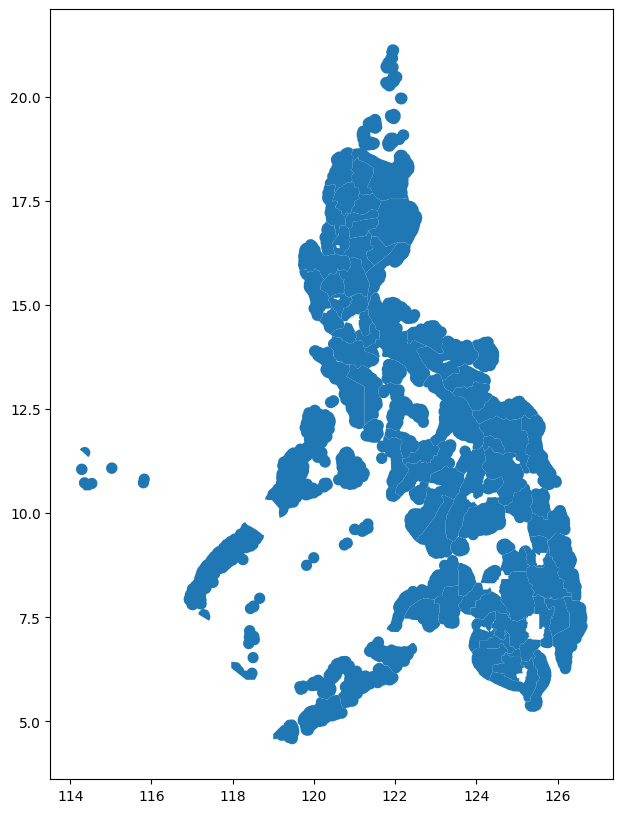

In [15]:
gpd_region.plot(figsize=(10,10))
plt.show()
plt.close()

### 1.2.2 provinces

In [17]:
gpd_provs = gpd.read_file('data/networks/ph_provinces.shp')
print(gpd_provs.shape)

(14, 5)


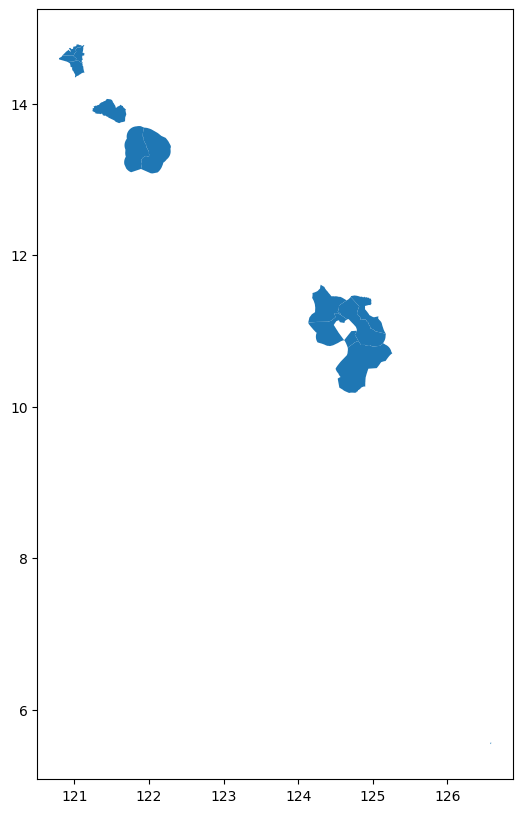

In [18]:
gpd_provs.plot(figsize=(10,10))
plt.show()
plt.close()

### 1.2.3 cities

In [21]:
gpd_cms = gpd.read_file('data/networks/ph_cities.shp')
print(gpd_cms.shape)

(906, 5)


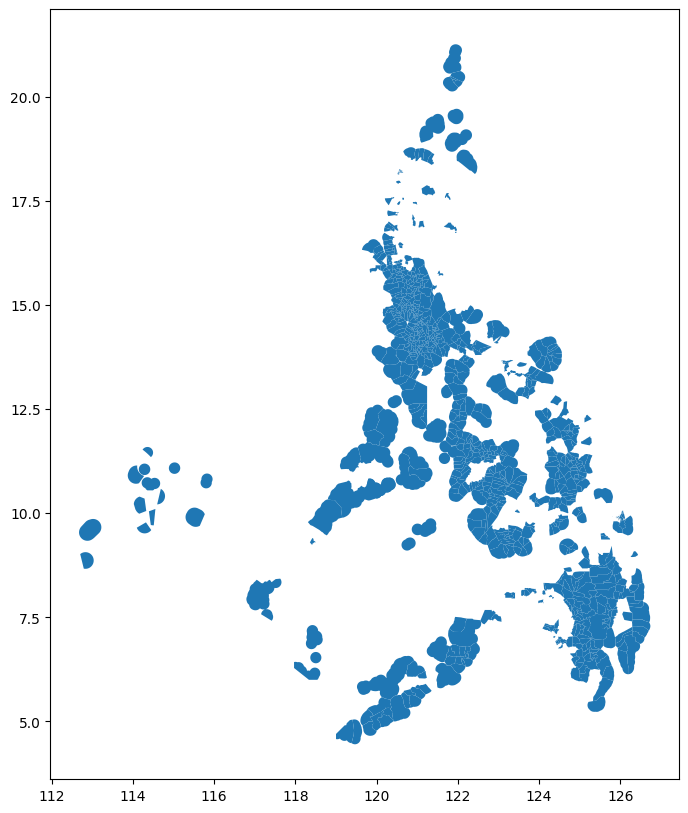

In [22]:
gpd_cms.plot(figsize=(10,10))
plt.show()
plt.close()

### 1.2.4 all

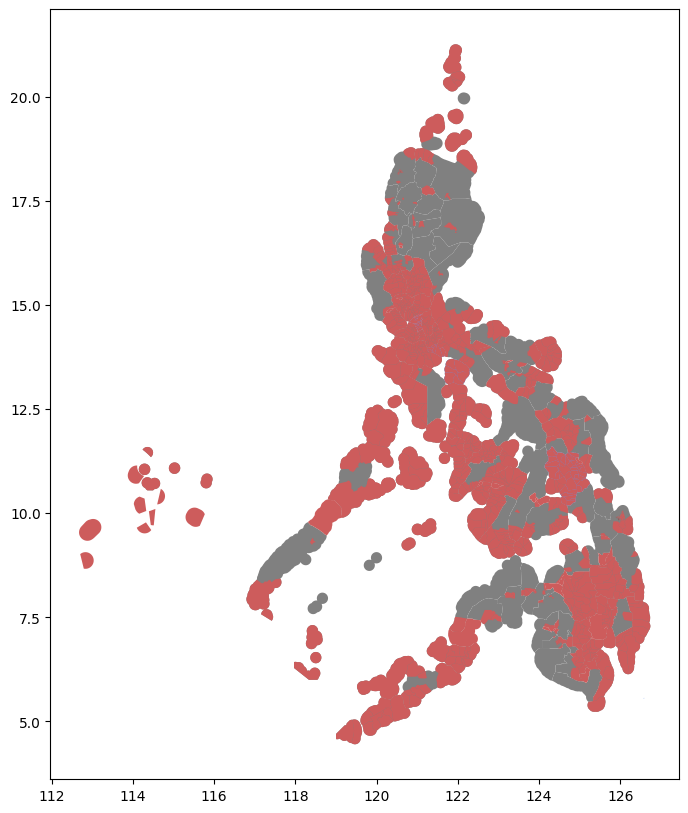

In [23]:
fig, ax = plt.subplots(figsize=(10,10))

gpd_region.plot(
    ax=ax,
    color='grey'
)

gpd_provs.plot(
    ax=ax,
    color='cornflowerblue'
)

gpd_cms.plot(
    ax=ax,
    color='indianred'
)

plt.show()
plt.close()

### 1.2.5 with GADM

In [24]:
path_shapes = os.path.join(get_path('output'), 'psgc_consolidated_matched.gpkg')
geodata = gpd.read_file(path_shapes)
print(geodata.shape)

(42048, 23)


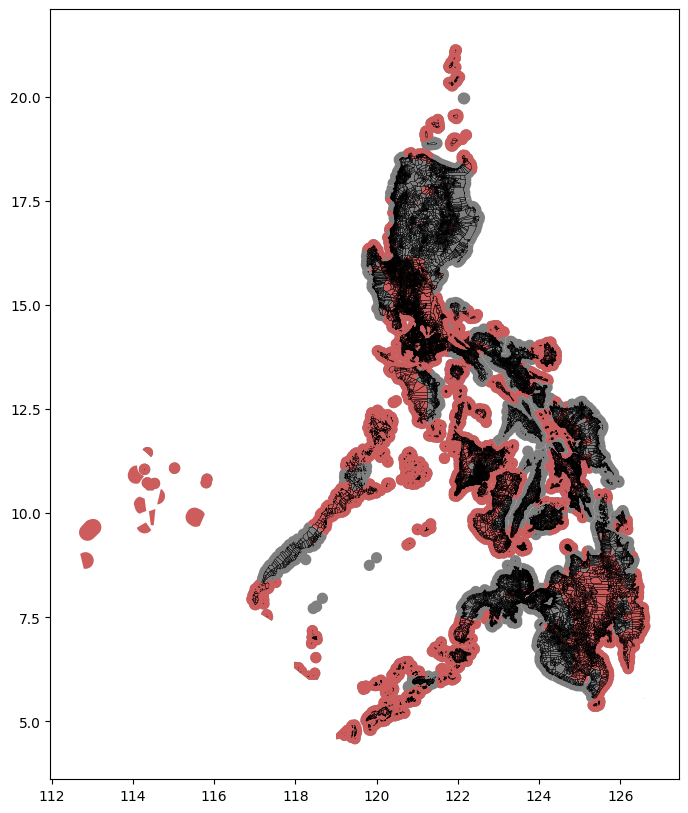

In [25]:
fig, ax = plt.subplots(figsize=(10,10))

gpd_region.plot(
    ax=ax,
    color='grey'
)

gpd_provs.plot(
    ax=ax,
    color='cornflowerblue'
)

gpd_cms.plot(
    ax=ax,
    color='indianred'
)

geodata.plot(
    ax=ax,
    color='none',
    linewidth=.25
)

plt.show()
plt.close()